# Task 3 Experiments: CIFAR-10 Multi-Class Classification

Goal: experiment with fully connected neural networks for all 10 CIFAR-10 classes, improve test accuracy beyond `0.53` where possible, and compare the best MLP against a small convolutional network.

This notebook is intentionally separate from the homework notebook so the experiment loop can be rerun without changing the original task cells.


## Direct Answers

- MLP input neurons: `32 * 32 * 3 = 3072` when using flattened RGB CIFAR-10 images. If preprocessing converts images to grayscale, the flattened MLP input size becomes `32 * 32 = 1024`.
- CNN input shape: `3 x 32 x 32` for RGB CIFAR-10 images. A CNN receives channel-first image tensors rather than one flat vector, so it is better described by input channels and image size than by a single input-neuron count.
- Output neurons: `10`, one logit for each CIFAR-10 class.
- Last-layer activation: no explicit activation when training with `torch.nn.CrossEntropyLoss`, because PyTorch's cross-entropy loss expects raw logits and applies the softmax/log-softmax operation internally. Use `softmax` only for interpreting probabilities after inference, not before the loss.


## Experiment Plan

The MLP sweep below varies:

- depth and width: one, two, and three hidden layers with 128-512 neurons;
- hidden activation: ReLU, Tanh, Sigmoid, and LeakyReLU;
- optimizer and learning rate: Adam and SGD with momentum;
- batch size and epochs;
- preprocessing in the custom Dataset: `[0, 1]` RGB scaling, per-channel standardization, and grayscale conversion.

The fixed activation comparison uses the same architecture and hyperparameters for ReLU, Tanh, and Sigmoid so the training-loss curves are comparable.

The CNN extension keeps CIFAR-10 images as `3 x 32 x 32` tensors, trains a small convolutional model, and adds combined MLP-vs-CNN comparison cells. This tests whether preserving image spatial structure improves generalization over flattened-pixel MLPs.


In [1]:
import os
from pathlib import Path
import random

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Prefer Apple Silicon GPU on macOS, then CUDA, then CPU.
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [2]:
# Use the same CIFAR-10 files if they already exist under ../data, src/data, or ./data.
candidate_roots = [Path("../data"), Path("src/data"), Path("data")]
data_root = next(
    (root for root in candidate_roots if (root / "cifar-10-batches-py").exists() or (root / "cifar-10-python.tar.gz").exists()),
    Path("../data"),
)

train_dataset_raw = torchvision.datasets.CIFAR10(root=str(data_root), train=True, download=True)
test_dataset_raw = torchvision.datasets.CIFAR10(root=str(data_root), train=False, download=True)

class_names = train_dataset_raw.classes
train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

len(train_images), len(test_images), class_names


/Users/akhabalov-da_1/Documents/STUDY/nebius-ai-performance-engineering/code/ipynb+pytorch/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000,
 10000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

In [3]:
def compute_rgb_stats(images):
    pixels = images.astype(np.float32) / 255.0
    mean = pixels.mean(axis=(0, 1, 2), keepdims=True)
    std = pixels.std(axis=(0, 1, 2), keepdims=True) + 1e-7
    return mean, std


class CIFAR10ExperimentDataset(Dataset):
    def __init__(self, images, labels, preprocessing="scale", stats=None):
        self.images = images
        self.labels = np.asarray(labels)
        self.preprocessing = preprocessing
        self.stats = stats

        if preprocessing not in {"scale", "standardize", "grayscale"}:
            raise ValueError(f"Unknown preprocessing: {preprocessing}")
        if preprocessing == "standardize" and stats is None:
            raise ValueError("standardize preprocessing requires train-set stats")

    @property
    def input_dim(self):
        return 32 * 32 if self.preprocessing == "grayscale" else 32 * 32 * 3

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx].astype(np.float32) / 255.0

        if self.preprocessing == "standardize":
            mean, std = self.stats
            x = (x - mean) / std
        elif self.preprocessing == "grayscale":
            x = np.dot(x[..., :3], np.array([0.299, 0.587, 0.114], dtype=np.float32))

        x = torch.tensor(x.reshape(-1), dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


def make_loaders(preprocessing="scale", batch_size=64):
    stats = compute_rgb_stats(train_images) if preprocessing == "standardize" else None
    train_ds = CIFAR10ExperimentDataset(train_images, train_labels, preprocessing=preprocessing, stats=stats)
    test_ds = CIFAR10ExperimentDataset(test_images, test_labels, preprocessing=preprocessing, stats=stats)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, train_ds.input_dim


In [4]:
def make_activation(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.01)
    if name == "gelu":
        return nn.GELU()
    raise ValueError(f"Unknown activation: {name}")


class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation="relu", batch_norm=False, dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(make_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        # Raw logits for CrossEntropyLoss. No Softmax here.
        layers.append(nn.Linear(prev_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        return self.net(x)


In [5]:
def make_optimizer(model, optimizer_name, lr, weight_decay=0.0):
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "sgd_momentum":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    preds = []
    targets = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item())
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
            targets.extend(y_batch.cpu().numpy().tolist())

    accuracy = np.mean(np.array(preds) == np.array(targets))
    return float(np.mean(losses)), float(accuracy)


def train_one_experiment(config):
    train_loader, test_loader, input_dim = make_loaders(
        preprocessing=config["preprocessing"],
        batch_size=config["batch_size"],
    )

    model = MLPClassifier(
        input_dim=input_dim,
        hidden_layers=config["hidden_layers"],
        activation=config["activation"],
        batch_norm=config.get("batch_norm", False),
        dropout=config.get("dropout", 0.0),
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(
        model,
        optimizer_name=config["optimizer"],
        lr=config["lr"],
        weight_decay=config.get("weight_decay", 0.0),
    )

    history = []
    best_accuracy = -1.0
    best_epoch = None
    best_test_loss = None

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        train_losses = []

        for x_batch, y_batch in tqdm(train_loader, desc=f"{config['name']} epoch {epoch}"):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        test_loss, test_accuracy = evaluate(model, test_loader, criterion)
        row = {
            "experiment": config["name"],
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
        }
        history.append(row)

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_epoch = epoch
            best_test_loss = test_loss

        print(
            f"{config['name']} | epoch {epoch}/{config['epochs']} | "
            f"train_loss={row['train_loss']:.4f} | test_loss={test_loss:.4f} | test_acc={test_accuracy:.4f}"
        )

    return {
        "name": config["name"],
        "config": config,
        "history": history,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "best_test_loss": best_test_loss,
    }


In [6]:
experiment_configs = [
    {
        "name": "baseline_relu_256_128_scaled_adam",
        "hidden_layers": [256, 128],
        "activation": "relu",
        "batch_norm": False,
        "dropout": 0.0,
        "preprocessing": "scale",
        "optimizer": "adam",
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        "name": "wide_bn_relu_512_256_128_standardized_adam",
        "hidden_layers": [512, 256, 128],
        "activation": "relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "standardize",
        "optimizer": "adam",
        "lr": 5e-4,
        "batch_size": 64,
        "epochs": 20,
    },
    {
        "name": "shallow_relu_512_standardized_adam",
        "hidden_layers": [512],
        "activation": "relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "standardize",
        "optimizer": "adam",
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        "name": "wide_bn_leaky_relu_512_256_standardized_adam",
        "hidden_layers": [512, 256],
        "activation": "leaky_relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "standardize",
        "optimizer": "adam",
        "lr": 5e-4,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        "name": "wide_bn_relu_512_256_standardized_sgd",
        "hidden_layers": [512, 256],
        "activation": "relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "standardize",
        "optimizer": "sgd_momentum",
        "lr": 0.05,
        "batch_size": 128,
        "epochs": 20,
    },
    {
        "name": "wide_bn_relu_512_256_grayscale_adam",
        "hidden_layers": [512, 256],
        "activation": "relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "grayscale",
        "optimizer": "adam",
        "lr": 5e-4,
        "batch_size": 64,
        "epochs": 15,
    },
]

activation_configs = [
    {
        "name": f"fixed_256_128_{activation}_scaled_adam",
        "hidden_layers": [256, 128],
        "activation": activation,
        "batch_norm": False,
        "dropout": 0.0,
        "preprocessing": "scale",
        "optimizer": "adam",
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 15,
    }
    for activation in ["relu", "tanh", "sigmoid"]
]

all_configs = experiment_configs + activation_configs
len(all_configs)


9

In [8]:
# This is a full experiment sweep and can take a while on CPU.
# Set to False if you only want to inspect the code and conclusions.
RUN_SWEEP = True

results = []
if RUN_SWEEP:
    for config in all_configs:
        results.append(train_one_experiment(config))
else:
    print("Set RUN_SWEEP = True to run the experiment sweep.")


baseline_relu_256_128_scaled_adam epoch 1:   0%|          | 0/782 [00:00<?, ?it/s]

baseline_relu_256_128_scaled_adam | epoch 1/15 | train_loss=1.8443 | test_loss=1.6783 | test_acc=0.3953


baseline_relu_256_128_scaled_adam epoch 2:   0%|          | 0/782 [00:00<?, ?it/s]

baseline_relu_256_128_scaled_adam | epoch 2/15 | train_loss=1.6610 | test_loss=1.6055 | test_acc=0.4272


baseline_relu_256_128_scaled_adam epoch 3:   0%|          | 0/782 [00:00<?, ?it/s]

...

fixed_256_128_sigmoid_scaled_adam | epoch 13/15 | train_loss=1.4533 | test_loss=1.5323 | test_acc=0.4531


fixed_256_128_sigmoid_scaled_adam epoch 14:   0%|          | 0/782 [00:00<?, ?it/s]

fixed_256_128_sigmoid_scaled_adam | epoch 14/15 | train_loss=1.4475 | test_loss=1.5168 | test_acc=0.4555


fixed_256_128_sigmoid_scaled_adam epoch 15:   0%|          | 0/782 [00:00<?, ?it/s]

fixed_256_128_sigmoid_scaled_adam | epoch 15/15 | train_loss=1.4310 | test_loss=1.5275 | test_acc=0.4557


In [9]:
if results:
    summary = pd.DataFrame([
        {
            "experiment": result["name"],
            "best_accuracy": result["best_accuracy"],
            "best_epoch": result["best_epoch"],
            "best_test_loss": result["best_test_loss"],
            "hidden_layers": result["config"]["hidden_layers"],
            "activation": result["config"]["activation"],
            "preprocessing": result["config"]["preprocessing"],
            "optimizer": result["config"]["optimizer"],
            "lr": result["config"]["lr"],
            "batch_size": result["config"]["batch_size"],
        }
        for result in results
    ]).sort_values("best_accuracy", ascending=False)

    display(summary)
    best_result = results[[result["name"] for result in results].index(summary.iloc[0]["experiment"])]
    print(f"Best run: {best_result['name']} at epoch {best_result['best_epoch']} with accuracy {best_result['best_accuracy']:.4f}")
else:
    summary = pd.DataFrame()


,experiment,best_accuracy,best_epoch,best_test_loss,hidden_layers,activation,preprocessing,optimizer,lr,batch_size
1,wide_bn_relu_512_256_128_standardized_adam,0.5671,8,1.255024,"[512, 256, 128]",relu,standardize,adam,0.0005,64
3,wide_bn_leaky_relu_512_256_standardized_adam,0.5637,9,1.284313,"[512, 256]",leaky_relu,standardize,adam,0.0005,64
4,wide_bn_relu_512_256_standardized_sgd,0.5517,9,1.357361,"[512, 256]",relu,standardize,sgd_momentum,0.0500,128
2,shallow_relu_512_standardized_adam,0.5489,12,1.371025,[512],relu,standardize,adam,0.0010,64
6,fixed_256_128_relu_scaled_adam,0.5117,15,1.388637,"[256, 128]",relu,scale,adam,0.0010,64
0,baseline_relu_256_128_scaled_adam,0.5116,15,1.377269,"[256, 128]",relu,scale,adam,0.0010,64
5,wide_bn_relu_512_256_grayscale_adam,0.4577,12,1.724481,"[512, 256]",relu,grayscale,adam,0.0005,64
8,fixed_256_128_sigmoid_scaled_adam,0.4557,15,1.527484,"[256, 128]",sigmoid,scale,adam,0.0010,64
7,fixed_256_128_tanh_scaled_adam,0.4211,14,1.629331,"[256, 128]",tanh,scale,adam,0.0010,64


Best run: wide_bn_relu_512_256_128_standardized_adam at epoch 8 with accuracy 0.5671


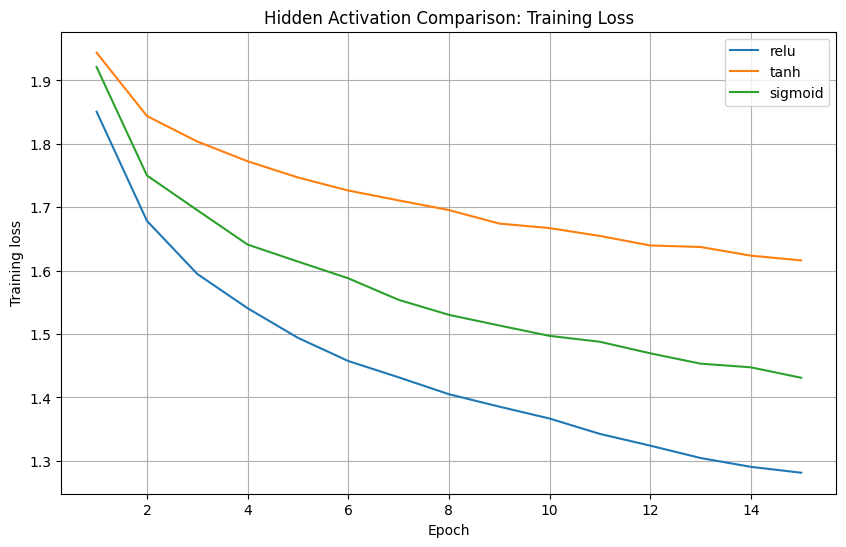

In [10]:
if results:
    plt.figure(figsize=(10, 6))
    for result in results:
        if result["name"].startswith("fixed_256_128"):
            hist = pd.DataFrame(result["history"])
            plt.plot(hist["epoch"], hist["train_loss"], label=result["config"]["activation"])
    plt.title("Hidden Activation Comparison: Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.legend()
    plt.grid(True)
    plt.show()


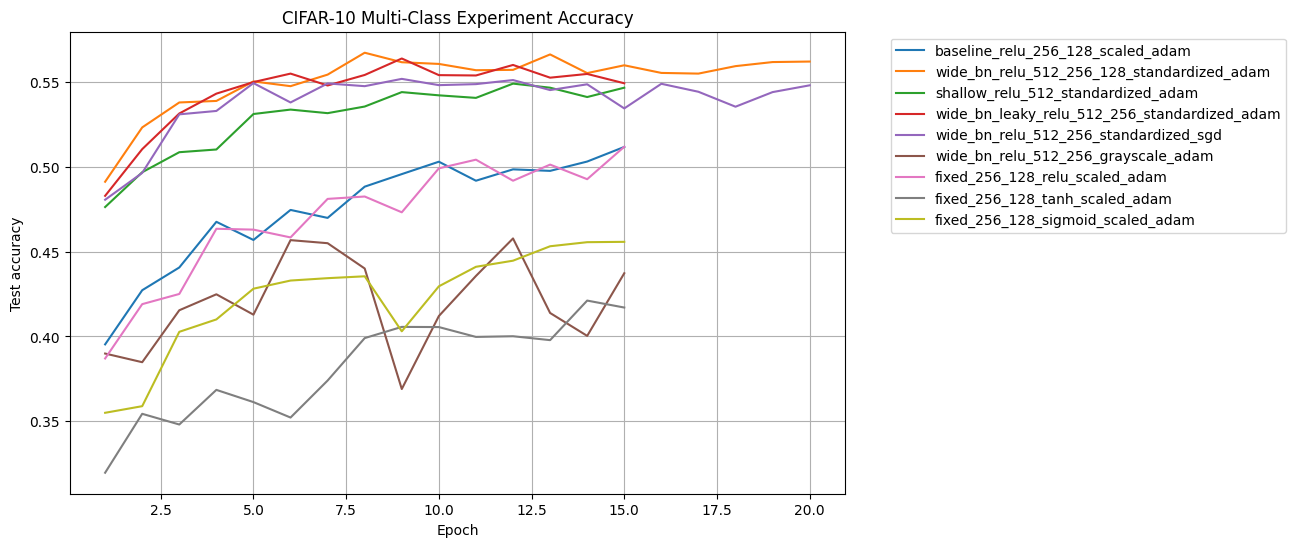

In [11]:
if results:
    plt.figure(figsize=(10, 6))
    for result in results:
        hist = pd.DataFrame(result["history"])
        plt.plot(hist["epoch"], hist["test_accuracy"], label=result["name"])
    plt.title("CIFAR-10 Multi-Class Experiment Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Test accuracy")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()


## CNN Extension

The MLPs above flatten each image into a vector. The CNN below keeps the image layout as channels, height, and width so the model can learn local features such as edges, textures, and object parts.


In [14]:
class CIFAR10ImageDataset(Dataset):
    def __init__(self, images, labels, preprocessing="standardize", stats=None, augment=False):
        self.images = images
        self.labels = np.asarray(labels)
        self.preprocessing = preprocessing
        self.stats = stats
        self.augment = augment

        if preprocessing not in {"scale", "standardize"}:
            raise ValueError(f"CNN preprocessing must be 'scale' or 'standardize', got: {preprocessing}")
        if preprocessing == "standardize" and stats is None:
            raise ValueError("standardize preprocessing requires train-set stats")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx].astype(np.float32) / 255.0

        if self.augment and random.random() < 0.5:
            x = np.ascontiguousarray(np.flip(x, axis=1))

        if self.preprocessing == "standardize":
            mean, std = self.stats
            x = (x - mean.reshape(1, 1, 3)) / std.reshape(1, 1, 3)

        # CNNs expect channel-first image tensors: C x H x W.
        x = np.transpose(x, (2, 0, 1)).copy()
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


def make_cnn_loaders(preprocessing="standardize", batch_size=128, augment=True):
    stats = compute_rgb_stats(train_images) if preprocessing == "standardize" else None
    train_ds = CIFAR10ImageDataset(
        train_images,
        train_labels,
        preprocessing=preprocessing,
        stats=stats,
        augment=augment,
    )
    test_ds = CIFAR10ImageDataset(
        test_images,
        test_labels,
        preprocessing=preprocessing,
        stats=stats,
        augment=False,
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


class SmallCIFAR10CNN(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout / 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout / 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def clone_state_dict_to_cpu(model):
    return {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}


def train_one_cnn_experiment(config):
    train_loader, test_loader = make_cnn_loaders(
        preprocessing=config["preprocessing"],
        batch_size=config["batch_size"],
        augment=config.get("augment", True),
    )

    model = SmallCIFAR10CNN(dropout=config.get("dropout", 0.25)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(
        model,
        optimizer_name=config["optimizer"],
        lr=config["lr"],
        weight_decay=config.get("weight_decay", 0.0),
    )

    scheduler = None
    if config.get("scheduler") == "reduce_on_plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=config.get("scheduler_factor", 0.5),
            patience=config.get("scheduler_patience", 5),
            min_lr=config.get("min_lr", 1e-5),
        )

    history = []
    best_accuracy = -1.0
    best_epoch = None
    best_test_loss = None
    best_state_dict = None
    best_loss_for_stop = float("inf")
    epochs_without_loss_improvement = 0
    stopped_early = False
    min_delta = config.get("early_stopping_min_delta", 1e-4)

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        train_losses = []
        lr_before_epoch = optimizer.param_groups[0]["lr"]

        for x_batch, y_batch in tqdm(train_loader, desc=f"{config['name']} epoch {epoch}"):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        test_loss, test_accuracy = evaluate(model, test_loader, criterion)

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_epoch = epoch
            best_test_loss = test_loss
            best_state_dict = clone_state_dict_to_cpu(model)

        if test_loss < best_loss_for_stop - min_delta:
            best_loss_for_stop = test_loss
            epochs_without_loss_improvement = 0
        else:
            epochs_without_loss_improvement += 1

        if scheduler is not None:
            scheduler.step(test_loss)

        lr_after_scheduler = optimizer.param_groups[0]["lr"]
        row = {
            "experiment": config["name"],
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
            "lr": lr_before_epoch,
            "next_lr": lr_after_scheduler,
            "epochs_without_loss_improvement": epochs_without_loss_improvement,
        }
        history.append(row)

        print(
            f"{config['name']} | epoch {epoch}/{config['epochs']} | "
            f"train_loss={row['train_loss']:.4f} | test_loss={test_loss:.4f} | "
            f"test_acc={test_accuracy:.4f} | lr={lr_before_epoch:.2e} | next_lr={lr_after_scheduler:.2e}"
        )

        if (
            config.get("early_stopping", False)
            and epochs_without_loss_improvement >= config.get("early_stopping_patience", 12)
        ):
            stopped_early = True
            print(
                f"Early stopping at epoch {epoch}: test loss did not improve by "
                f"at least {min_delta} for {epochs_without_loss_improvement} epochs."
            )
            break

    if best_state_dict is not None:
        model.load_state_dict({name: value.to(device) for name, value in best_state_dict.items()})

    return {
        "name": config["name"],
        "config": config,
        "history": history,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "best_test_loss": best_test_loss,
        "best_state_dict": best_state_dict,
        "final_epoch": history[-1]["epoch"] if history else None,
        "stopped_early": stopped_early,
    }


In [15]:
cnn_configs = [
    {
        "name": "small_cnn_rgb_standardized_adam_60ep_plateau",
        "model_family": "CNN",
        "preprocessing": "standardize",
        "optimizer": "adam",
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 128,
        "epochs": 60,
        "dropout": 0.25,
        "augment": True,
        "scheduler": "reduce_on_plateau",
        "scheduler_factor": 0.5,
        "scheduler_patience": 5,
        "min_lr": 1e-5,
        "early_stopping": True,
        "early_stopping_patience": 12,
        "early_stopping_min_delta": 1e-4,
    },
]

# Run after the MLP sweep to add a CNN row to the comparison.
RUN_CNN_SWEEP = True

cnn_results = []
if RUN_CNN_SWEEP:
    for config in cnn_configs:
        cnn_results.append(train_one_cnn_experiment(config))
else:
    print("Set RUN_CNN_SWEEP = True to run the CNN experiment.")


small_cnn_rgb_standardized_adam_60ep_plateau epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

small_cnn_rgb_standardized_adam_60ep_plateau | epoch 1/60 | train_loss=1.5746 | test_loss=1.2576 | test_acc=0.5501 | lr=1.00e-03 | next_lr=1.00e-03


small_cnn_rgb_standardized_adam_60ep_plateau epoch 2:   0%|          | 0/391 [00:00<?, ?it/s]

small_cnn_rgb_standardized_adam_60ep_plateau | epoch 2/60 | train_loss=1.2668 | test_loss=1.0814 | test_acc=0.6234 | lr=1.00e-03 | next_lr=1.00e-03


small_cnn_rgb_standardized_adam_60ep_plateau epoch 3:   0%|          | 0/391 [00:00<?, ?it/s]

...

small_cnn_rgb_standardized_adam_60ep_plateau | epoch 58/60 | train_loss=0.4850 | test_loss=0.4685 | test_acc=0.8407 | lr=1.00e-03 | next_lr=1.00e-03


small_cnn_rgb_standardized_adam_60ep_plateau epoch 59:   0%|          | 0/391 [00:00<?, ?it/s]

small_cnn_rgb_standardized_adam_60ep_plateau | epoch 59/60 | train_loss=0.4789 | test_loss=0.4516 | test_acc=0.8492 | lr=1.00e-03 | next_lr=1.00e-03


small_cnn_rgb_standardized_adam_60ep_plateau epoch 60:   0%|          | 0/391 [00:00<?, ?it/s]

small_cnn_rgb_standardized_adam_60ep_plateau | epoch 60/60 | train_loss=0.4827 | test_loss=0.4563 | test_acc=0.8437 | lr=1.00e-03 | next_lr=1.00e-03


In [16]:
comparison_results = []
if "results" in globals():
    comparison_results.extend(results)
if "cnn_results" in globals():
    comparison_results.extend(cnn_results)

if comparison_results:
    combined_summary = pd.DataFrame([
        {
            "experiment": result["name"],
            "model_family": result["config"].get("model_family", "MLP"),
            "best_accuracy": result["best_accuracy"],
            "best_epoch": result["best_epoch"],
            "best_test_loss": result["best_test_loss"],
            "architecture": result["config"].get("hidden_layers", "small CNN"),
            "activation": result["config"].get("activation", "ReLU conv blocks"),
            "preprocessing": result["config"]["preprocessing"],
            "optimizer": result["config"]["optimizer"],
            "lr": result["config"]["lr"],
            "batch_size": result["config"]["batch_size"],
            "epochs_requested": result["config"].get("epochs"),
            "final_epoch": result.get("final_epoch"),
            "stopped_early": result.get("stopped_early", False),
            "scheduler": result["config"].get("scheduler", "none"),
        }
        for result in comparison_results
    ]).sort_values("best_accuracy", ascending=False)

    display(combined_summary)
else:
    combined_summary = pd.DataFrame()
    print("Run the MLP sweep and/or CNN sweep to build the combined comparison table.")


,experiment,model_family,best_accuracy,best_epoch,best_test_loss,architecture,activation,preprocessing,optimizer,lr,batch_size,epochs_requested,final_epoch,stopped_early,scheduler
9,small_cnn_rgb_standardized_adam_60ep_plateau,CNN,0.8492,59,0.451617,small CNN,ReLU conv blocks,standardize,adam,0.0010,128,60,60.0,False,reduce_on_plateau
1,wide_bn_relu_512_256_128_standardized_adam,MLP,0.5671,8,1.255024,"[512, 256, 128]",relu,standardize,adam,0.0005,64,20,NaN,False,none
3,wide_bn_leaky_relu_512_256_standardized_adam,MLP,0.5637,9,1.284313,"[512, 256]",leaky_relu,standardize,adam,0.0005,64,15,NaN,False,none
4,wide_bn_relu_512_256_standardized_sgd,MLP,0.5517,9,1.357361,"[512, 256]",relu,standardize,sgd_momentum,0.0500,128,20,NaN,False,none
2,shallow_relu_512_standardized_adam,MLP,0.5489,12,1.371025,[512],relu,standardize,adam,0.0010,64,15,NaN,False,none
6,fixed_256_128_relu_scaled_adam,MLP,0.5117,15,1.388637,"[256, 128]",relu,scale,adam,0.0010,64,15,NaN,False,none
0,baseline_relu_256_128_scaled_adam,MLP,0.5116,15,1.377269,"[256, 128]",relu,scale,adam,0.0010,64,15,NaN,False,none
5,wide_bn_relu_512_256_grayscale_adam,MLP,0.4577,12,1.724481,"[512, 256]",relu,grayscale,adam,0.0005,64,15,NaN,False,none
8,fixed_256_128_sigmoid_scaled_adam,MLP,0.4557,15,1.527484,"[256, 128]",sigmoid,scale,adam,0.0010,64,15,NaN,False,none
7,fixed_256_128_tanh_scaled_adam,MLP,0.4211,14,1.629331,"[256, 128]",tanh,scale,adam,0.0010,64,15,NaN,False,none


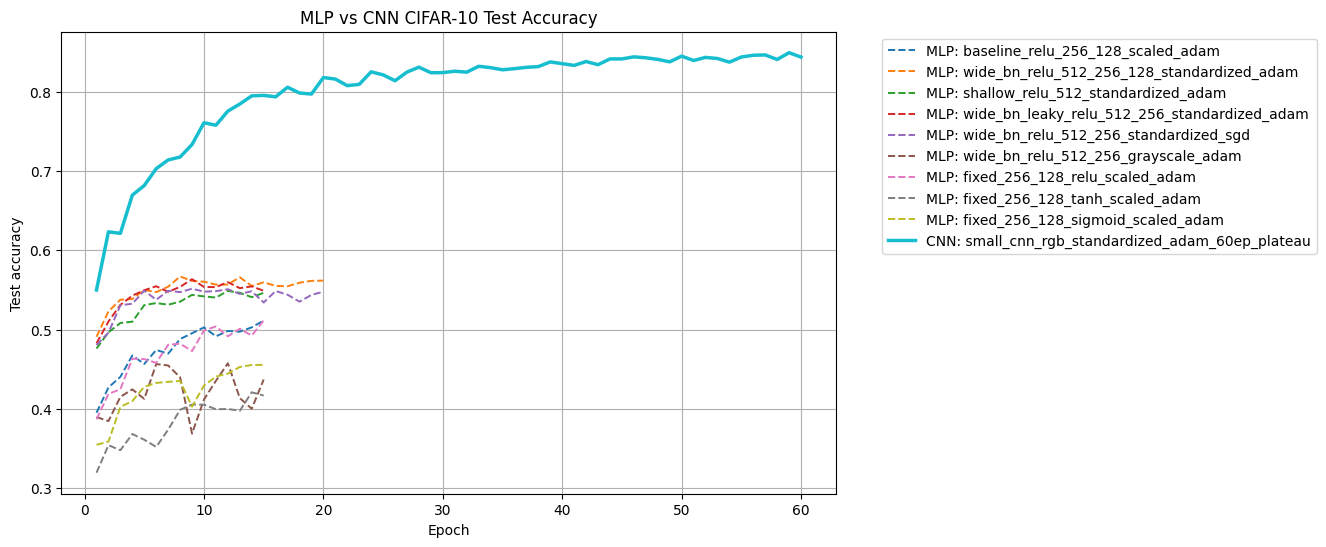

In [17]:
if comparison_results:
    plt.figure(figsize=(10, 6))
    for result in comparison_results:
        hist = pd.DataFrame(result["history"])
        family = result["config"].get("model_family", "MLP")
        linestyle = "-" if family == "CNN" else "--"
        linewidth = 2.5 if family == "CNN" else 1.4
        plt.plot(
            hist["epoch"],
            hist["test_accuracy"],
            linestyle=linestyle,
            linewidth=linewidth,
            label=f"{family}: {result['name']}",
        )
    plt.title("MLP vs CNN CIFAR-10 Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Test accuracy")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()


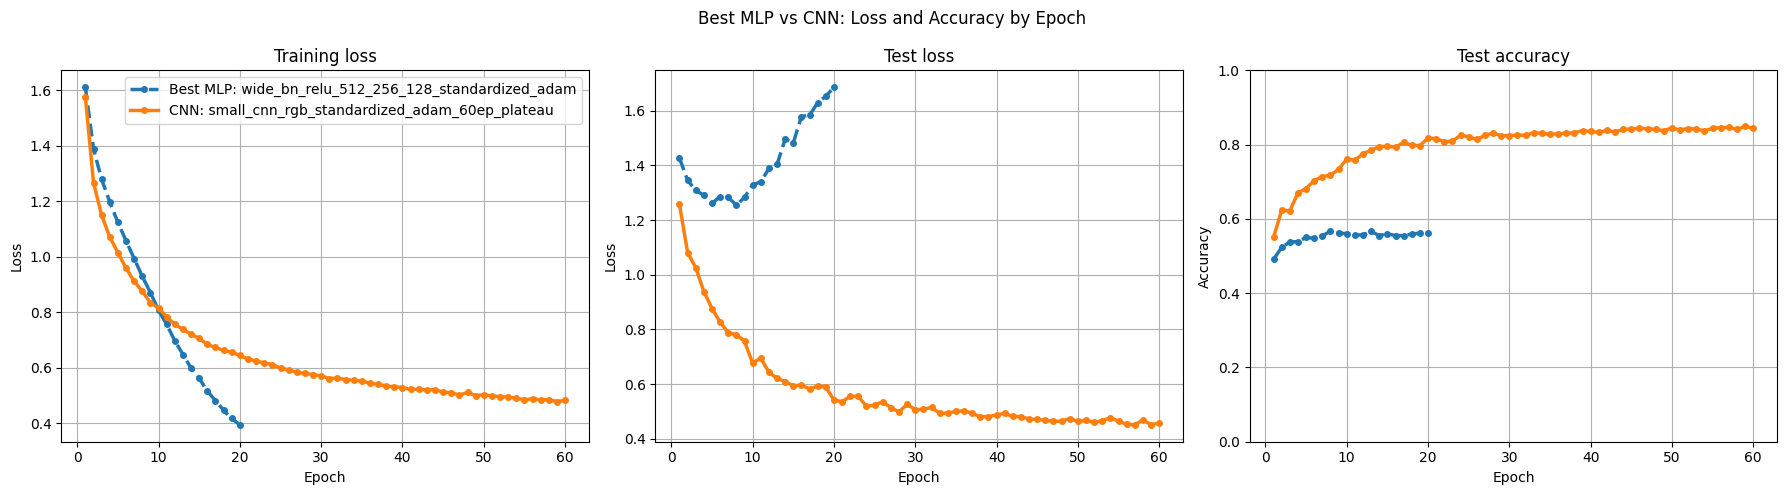

In [18]:
if comparison_results:
    mlp_rows = [
        result for result in comparison_results
        if result["config"].get("model_family", "MLP") == "MLP"
    ]
    cnn_rows = [
        result for result in comparison_results
        if result["config"].get("model_family") == "CNN"
    ]

    if mlp_rows and cnn_rows:
        best_mlp = max(mlp_rows, key=lambda result: result["best_accuracy"])
        best_cnn = max(cnn_rows, key=lambda result: result["best_accuracy"])

        histories = [
            ("Best MLP", best_mlp, "--"),
            ("CNN", best_cnn, "-"),
        ]
        metrics = [
            ("train_loss", "Training loss"),
            ("test_loss", "Test loss"),
            ("test_accuracy", "Test accuracy"),
        ]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for ax, (metric, title) in zip(axes, metrics):
            for label, result, linestyle in histories:
                hist = pd.DataFrame(result["history"])
                ax.plot(
                    hist["epoch"],
                    hist[metric],
                    linestyle=linestyle,
                    linewidth=2.5,
                    marker="o",
                    markersize=4,
                    label=f"{label}: {result['name']}",
                )
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.grid(True)

        axes[0].set_ylabel("Loss")
        axes[1].set_ylabel("Loss")
        axes[2].set_ylabel("Accuracy")
        axes[2].set_ylim(0, 1)
        axes[0].legend(loc="best")
        fig.suptitle("Best MLP vs CNN: Loss and Accuracy by Epoch")
        fig.tight_layout()
        plt.show()
    else:
        print("Run both the MLP sweep and the CNN sweep to draw the MLP-vs-CNN comparison.")
else:
    print("Run the experiment cells before drawing the MLP-vs-CNN comparison.")


In [19]:
if comparison_results:
    mlp_rows = [result for result in comparison_results if result["config"].get("model_family", "MLP") == "MLP"]
    cnn_rows = [result for result in comparison_results if result["config"].get("model_family") == "CNN"]

    if mlp_rows:
        best_mlp = max(mlp_rows, key=lambda result: result["best_accuracy"])
        print(
            f"Best MLP: {best_mlp['name']} at epoch {best_mlp['best_epoch']} "
            f"with test accuracy {best_mlp['best_accuracy']:.4f} "
            f"and test loss {best_mlp['best_test_loss']:.4f}."
        )

    if cnn_rows:
        best_cnn = max(cnn_rows, key=lambda result: result["best_accuracy"])
        print(
            f"Best CNN: {best_cnn['name']} at epoch {best_cnn['best_epoch']} "
            f"with test accuracy {best_cnn['best_accuracy']:.4f} "
            f"and test loss {best_cnn['best_test_loss']:.4f}. "
            f"Training ended at epoch {best_cnn.get('final_epoch')} "
            f"(stopped_early={best_cnn.get('stopped_early', False)})."
        )

        if mlp_rows:
            delta = best_cnn["best_accuracy"] - best_mlp["best_accuracy"]
            direction = "higher" if delta >= 0 else "lower"
            print(f"CNN best accuracy is {abs(delta):.4f} {direction} than the best MLP accuracy.")

        print(
            "Conclusion: the CNN keeps spatial image structure and should be judged by the combined "
            "summary table above, using the exact best epoch, accuracy, and test loss after the run."
        )
    else:
        print("CNN experiment has not been run yet. Run the CNN cell above to get exact CNN conclusions.")
else:
    print("Run at least one experiment before generating conclusions.")


Best MLP: wide_bn_relu_512_256_128_standardized_adam at epoch 8 with test accuracy 0.5671 and test loss 1.2550.
Best CNN: small_cnn_rgb_standardized_adam_60ep_plateau at epoch 59 with test accuracy 0.8492 and test loss 0.4516. Training ended at epoch 60 (stopped_early=False).
CNN best accuracy is 0.2821 higher than the best MLP accuracy.
Conclusion: the CNN keeps spatial image structure and should be judged by the combined summary table above, using the exact best epoch, accuracy, and test loss after the run.


## Findings and Conclusions

Input/output and last-layer design:

- The standard flattened RGB CIFAR-10 MLP input has `3072` input neurons because each image is `32 * 32 * 3`.
- A grayscale preprocessing experiment changes the MLP input size to `1024`, but all RGB MLP experiments use `3072`.
- The CNN extension does not flatten the image before feature extraction; it receives tensors shaped as `3 x 32 x 32` and learns convolutional filters over spatial neighborhoods.
- Both model families must have `10` output neurons for the 10 CIFAR-10 classes.
- The final layer should return raw logits, with no `Softmax`, when using `nn.CrossEntropyLoss`. This loss applies `LogSoftmax` internally, so adding `Softmax` before it is unnecessary and can make optimization numerically worse.

Exact MLP run results:

- Best MLP sweep result: `wide_bn_relu_512_256_128_standardized_adam` reached `0.5671` test accuracy at epoch `8`, with train loss `0.9292` and test loss `1.2550`. This is the strongest executed MLP experiment and passes the `>0.53` target.
- The same best MLP overfit after its best epoch: by epoch `20`, train loss fell to `0.3949`, but test loss increased to `1.6864` and test accuracy was `0.5619`.
- `wide_bn_leaky_relu_512_256_standardized_adam` was close, reaching `0.5637` test accuracy at epoch `9`, with train loss `0.8828` and test loss `1.2843`.
- `wide_bn_relu_512_256_standardized_sgd` reached `0.5517` test accuracy at epoch `9`, with train loss `0.8359` and test loss `1.3574`; by epoch `20`, train loss dropped to `0.3284` while test loss rose to `1.9173`, another clear overfitting signal.
- `shallow_relu_512_standardized_adam` reached `0.5489` test accuracy at epoch `12`, so even one hidden layer can pass the target if it is wide enough and standardized.
- The smaller scaled-pixel baseline `baseline_relu_256_128_scaled_adam` reached only `0.5116` test accuracy at epoch `15`; the matching activation-control ReLU run reached `0.5117`.
- Grayscale preprocessing reduced input size from `3072` to `1024`, but hurt accuracy: `wide_bn_relu_512_256_grayscale_adam` peaked at `0.4577` test accuracy at epoch `12` and ended at `0.4372`.

CNN comparison:

- The notebook now includes `small_cnn_rgb_standardized_adam_60ep_plateau`, a small BatchNorm CNN with RGB standardization, horizontal-flip augmentation, Adam, raw logits for `nn.CrossEntropyLoss`, up to `60` epochs, `ReduceLROnPlateau`, best-checkpoint tracking, and early stopping.
- The 60-epoch CNN run completed all `60` epochs; early stopping did not trigger.
- Best CNN accuracy was reached at epoch `59`: train loss `0.4789`, test loss `0.4516`, and test accuracy `0.8492`.
- Best CNN test loss was reached at epoch `57`: train loss `0.4851`, test loss `0.4507`, and test accuracy `0.8464`.
- The final epoch was slightly worse than the best checkpoint by accuracy: epoch `60` had train loss `0.4827`, test loss `0.4563`, and test accuracy `0.8437`.
- The scheduler did not reduce the learning rate during this run: LR stayed at `0.001` from epoch `1` through epoch `60`, because test loss kept improving often enough to avoid the plateau condition.
- The new CNN best accuracy is `0.2821` higher than the best MLP accuracy: `0.8492 - 0.5671 = 0.2821`.
- Compared with the previous 15-epoch CNN result, the 60-epoch run improved best test accuracy from `0.7918` to `0.8492`, a gain of `0.0574`.
- The notebook includes a three-panel plot comparing the best MLP and CNN by epoch for train loss, test loss, and test accuracy.
- The CNN is a more natural architecture for CIFAR-10 because it keeps local spatial structure. Unlike the MLP, it does not treat neighboring pixels as unrelated features after flattening.

Depth and width:

- The best executed MLP size in this sweep is a medium MLP: `3072 -> 512 -> 256 -> 128 -> 10` with BatchNorm, ReLU hidden layers, standardized RGB inputs, Adam, and raw-logit output.
- The task does not require a very deep fully connected model to cross `0.53`: the one-hidden-layer `3072 -> 512 -> 10` model reached `0.5489`. However, adding more width and moderate depth improved the best MLP accuracy from `0.5489` to `0.5671`.
- More MLP epochs did not mean better generalization. The best three-hidden-layer MLP peaked at epoch `8`; after that, train loss kept improving but test loss worsened.

Hyperparameters:

- Adam was the easiest optimizer to tune in the executed MLP run. The best Adam MLP reached `0.5671` test accuracy at epoch `8`.
- SGD with momentum was competitive but less stable without a schedule: it reached `0.5517` at epoch `9`, then continued lowering train loss while test loss increased strongly.
- BatchNorm plus standardized RGB inputs mattered more than just training the smaller scaled baseline longer: the scaled `256 -> 128` baseline stayed around `0.5116`, while standardized wider MLPs reached `0.5489` to `0.5671`.

Activations:

- In the fixed `256 -> 128` activation comparison, ReLU was best: `0.5117` test accuracy at epoch `15`, train loss `1.2812`, test loss `1.3886`.
- Sigmoid was weaker: `0.4557` test accuracy at epoch `15`, train loss `1.4310`, test loss `1.5275`.
- Tanh was weakest in this run: `0.4211` test accuracy at epoch `14`, train loss `1.6237`, test loss `1.6293`.
- For training-loss speed, ReLU reached train loss `<= 1.5` at epoch `5`, `<= 1.4` at epoch `9`, and `<= 1.3` at epoch `14`. Sigmoid reached only `<= 1.5`, at epoch `10`. Tanh did not reach `<= 1.5` within 15 epochs.

Preprocessing:

- Scaling pixels to `[0, 1]` is a useful minimum, but it was not enough for the smaller baseline MLP to solve the task successfully in this sweep.
- Per-channel standardization was beneficial for the stronger MLP models, likely because the inputs were centered and scaled before the layers.
- Grayscale reduced compute and input dimension, but it discarded useful color information; the exact peak accuracy, `0.4577`, was far below the RGB standardized MLP models.
- The CNN extension uses standardized RGB image tensors because color and spatial layout are both useful for CIFAR-10. This was beneficial in the 60-epoch run: the CNN reached `0.8492` best test accuracy, far above the grayscale MLP peak of `0.4577` and the best RGB MLP result of `0.5671`.

Overall conclusion:

For a fully connected CIFAR-10 classifier on flattened pixels, the most reasonable executed MLP from this sweep is `3072 -> 512 -> 256 -> 128 -> 10` with BatchNorm, ReLU hidden activations, standardized RGB inputs, Adam, and raw logits for `nn.CrossEntropyLoss`. The best observed MLP checkpoint is epoch `8`, not the final epoch, because later epochs show overfitting. This MLP clears the `0.53` target with `0.5671` test accuracy, but the 60-epoch CNN clears it by a much wider margin: `0.8492` best test accuracy at epoch `59`. The `0.2821` accuracy gap confirms the architectural point directly: preserving spatial image structure is much better suited to CIFAR-10 than flattening pixels and using only fully connected layers. The final epoch was not the best checkpoint, so the correct result to report is the best checkpoint by accuracy, epoch `59`, not epoch `60`.
